In [4]:
!unzip '/content/archive.zip'

Archive:  /content/archive.zip
  inflating: scanner_data.csv        


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('/content/archive.zip')
df

,Unnamed: 0,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount
0,1,02/01/2016,2547,1,X52,0EM7L,1.0,3.13
1,2,02/01/2016,822,2,2ML,68BRQ,1.0,5.46
2,3,02/01/2016,3686,3,0H2,CZUZX,1.0,6.35
3,4,02/01/2016,3719,4,0H2,549KK,1.0,5.59
4,5,02/01/2016,9200,5,0H2,K8EHH,1.0,6.88
...,...,...,...,...,...,...,...,...
131701,131702,04/07/2016,20203,32900,IEV,FO112,3.0,6.46
131702,131703,04/07/2016,20203,32900,N8U,I36F2,1.0,4.50
131703,131704,04/07/2016,20203,32900,U5F,4X8P4,1.0,5.19
131704,131705,04/07/2016,20203,32900,0H2,ZVTO4,1.0,4.57


In [7]:
frequency =  df.groupby('Customer_ID').count()[['Transaction_ID']]
frequency

,Transaction_ID
Customer_ID,
1,2
2,2
3,3
4,5
5,5
...,...
22621,2
22622,1
22623,2


In [8]:
frequency.columns = ['frequency']
frequency

,frequency
Customer_ID,
1,2
2,2
3,3
4,5
5,5
...,...
22621,2
22622,1
22623,2


In [9]:
frequency = pd.qcut(frequency['frequency'].rank(method = 'first'), q=5, labels=[1,2,3,4,5])

In [10]:
frequency

,frequency
Customer_ID,
1,2
2,2
3,3
4,4
5,4
...,...
22621,3
22622,2
22623,3


In [11]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')


In [12]:
df

,Unnamed: 0,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount
0,1,2016-01-02,2547,1,X52,0EM7L,1.0,3.13
1,2,2016-01-02,822,2,2ML,68BRQ,1.0,5.46
2,3,2016-01-02,3686,3,0H2,CZUZX,1.0,6.35
3,4,2016-01-02,3719,4,0H2,549KK,1.0,5.59
4,5,2016-01-02,9200,5,0H2,K8EHH,1.0,6.88
...,...,...,...,...,...,...,...,...
131701,131702,2016-07-04,20203,32900,IEV,FO112,3.0,6.46
131702,131703,2016-07-04,20203,32900,N8U,I36F2,1.0,4.50
131703,131704,2016-07-04,20203,32900,U5F,4X8P4,1.0,5.19
131704,131705,2016-07-04,20203,32900,0H2,ZVTO4,1.0,4.57


In [13]:
recency = df.groupby('Customer_ID').max()[['Date']]
recency

,Date
Customer_ID,
1,2016-01-22
2,2016-06-19
3,2016-01-02
4,2016-11-09
5,2016-07-05
...,...
22621,2016-12-10
22622,2016-12-16
22623,2016-12-21


In [14]:
df['Date'].max()


Timestamp('2016-12-31 00:00:00')

In [15]:
recency['day_dif'] = recency['Date'].apply(lambda x: (df['Date'].max() - x).days)

In [16]:
recency

,Date,day_dif
Customer_ID,,
1,2016-01-22,344
2,2016-06-19,195
3,2016-01-02,364
4,2016-11-09,52
5,2016-07-05,179
...,...,...
22621,2016-12-10,21
22622,2016-12-16,15
22623,2016-12-21,10


In [17]:
recency['recency'] = pd.qcut(recency['day_dif'].rank(method = 'first'), q=5, labels=[5,4,3,2,1])

In [18]:
recency

,Date,day_dif,recency
Customer_ID,,,
1,2016-01-22,344,1
2,2016-06-19,195,3
3,2016-01-02,364,1
4,2016-11-09,52,4
5,2016-07-05,179,3
...,...,...,...
22621,2016-12-10,21,5
22622,2016-12-16,15,5
22623,2016-12-21,10,5


In [19]:
rfm_t = recency.merge(frequency, on='Customer_ID')
rfm_t

,Date,day_dif,recency,frequency
Customer_ID,,,,
1,2016-01-22,344,1,2
2,2016-06-19,195,3,2
3,2016-01-02,364,1,3
4,2016-11-09,52,4,4
5,2016-07-05,179,3,4
...,...,...,...,...
22621,2016-12-10,21,5,3
22622,2016-12-16,15,5,2
22623,2016-12-21,10,5,3


In [20]:
rfm_t['recency'].unique()

[1, 3, 4, 2, 5]
Categories (5, int64): [5 < 4 < 3 < 2 < 1]

In [21]:
segments = []
for fs,rs in zip (rfm_t['frequency'],rfm_t['recency']):
  if fs >= 5 and rs >= 5:
    segments.append("champions")
  elif fs >= 5 and rs >=3 and rs <=5:
    segments.append("loyal")
  elif fs >= 2 and fs <= 3 and rs >= 5:
    segments.append("potential loyalists")
  elif fs == 1 and rs == 4:
    segments.append("promising")
  elif fs == 1 and rs == 5:
    segments.append("new customers")
  elif fs >= 5 and rs<= 2:
    segments.append("cannot lose them")
  elif fs >= 3 and fs <= 4 and rs <= 2:
    segments.append("at risk")
  elif fs == 3 and rs == 3:
    segments.append("need attention")
  elif fs <= 2 and rs == 3:
    segments.append("about to sleep")

  else:
    segments.append("hibernating")

In [22]:
rfm_t['cust_seg'] = segments

In [26]:
rfm_t

,Date,day_dif,recency,frequency,cust_seg
Customer_ID,,,,,
1,2016-01-22,344,1,2,hibernating
2,2016-06-19,195,3,2,about to sleep
3,2016-01-02,364,1,3,at risk
4,2016-11-09,52,4,4,hibernating
5,2016-07-05,179,3,4,hibernating
...,...,...,...,...,...
22621,2016-12-10,21,5,3,potential loyalists
22622,2016-12-16,15,5,2,potential loyalists
22623,2016-12-21,10,5,3,potential loyalists


In [23]:
rfm_t['cust_seg'].value_counts()

,count
cust_seg,
hibernating,9870
at risk,3157
champions,2006
about to sleep,1914
loyal,1497
potential loyalists,1236
need attention,1065
cannot lose them,1022
promising,544


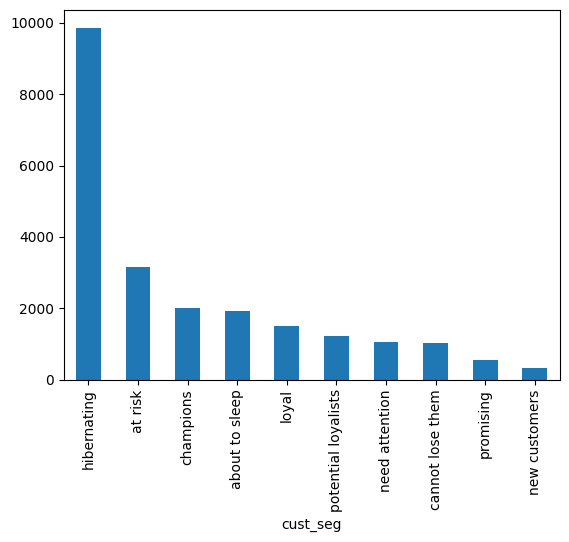

In [28]:
rfm_t['cust_seg'].value_counts().plot(kind = 'bar')
plt.show()